<a href="https://colab.research.google.com/github/chiba-yukikoto/MachineLearning-FinalProject/blob/main/ESG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VeriPromiseESG 2026 ESG 承諾驗證工作坊
## 使用 BERT 進行多任務分類

**工作坊時間**: 約 60 分鐘  
**難度**: 中級（需具備基礎 Python 知識）

### 今天的學習目標
1. 了解 ESG（環境、社會、治理）承諾驗證任務
2. 掌握如何使用 BERT 進行多標籤分類
3. 實作完整的訓練與評估流程

### 任務說明
給定一段 ESG 報告文字，模型需要同時預測四個欄位：
| 欄位 | 說明 | 類別 |
|------|------|------|
| `promise_status` | 是否有承諾 | Yes / No |
| `verification_timeline` | 承諾時程 | already / within_2_years / between_2_and_5_years / longer_than_5_years / N/A |
| `evidence_status` | 是否有佐證 | Yes / No / N/A |
| `evidence_quality` | 佐證品質 | Clear / Not Clear / Misleading / N/A |

### 評分方式
最終分數 = 加權平均 Macro F1：
- `promise_status` × 0.20
- `evidence_status` × 0.30  
- `evidence_quality` × 0.35
- `verification_timeline` × 0.15

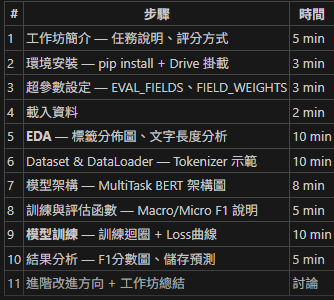

## Step 1: 安裝套件

首先安裝必要的 Python 套件。在 Google Colab 上執行以下指令。

> **說明**：
> - `transformers` — HuggingFace 提供的預訓練模型庫
> - `torch` — PyTorch 深度學習框架
> - `scikit-learn` — 評估指標計算
> - `pandas` / `matplotlib` — 資料分析與視覺化

In [ ]:
# 安裝必要套件（Colab 環境）
!pip install transformers torch scikit-learn pandas matplotlib seaborn -q
print("套件安裝完成！")

套件安裝完成！


In [ ]:
# 安裝 imbalanced-learn 套件以進行過取樣
!pip install imbalanced-learn -q
print("imbalanced-learn 安裝完成！")

imbalanced-learn 安裝完成！


In [ ]:
# 從 GitHub 下載公開資料集（不需要 Google Drive）
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/veripromiseesg/veripromiseesgdataset/ac91c1c8b5d116edf6fc44cccc1ee3b618f5a207/vpesg4ktrain1000v1.json"
urllib.request.urlretrieve(DATA_URL, "vpesg4k_train_1000.json")
print("資料下載完成！")

資料下載完成！


In [ ]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 中文字型設定（Colab）
matplotlib.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("所有套件載入完成！")
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")

所有套件載入完成！
PyTorch 版本: 2.11.0+cu128
CUDA 可用: True


## Step 2: 設定超參數與標籤對應

在開始之前，我們先定義所有重要的超參數與標籤映射表。

### 重要參數說明
- **MODEL_NAME**: 使用 `bert-base-chinese`，這是 Google 發布的中文 BERT 模型
- **MAX_LEN**: 輸入文字的最大 Token 長度（256）
- **BATCH_SIZE**: 每次訓練的樣本數（16）
- **EPOCHS**: 訓練完整資料集的次數（5）
- **LR**: 學習率，建議 BERT fine-tuning 使用 2e-5

### 為什麼用 bert-base-chinese？
BERT（Bidirectional Encoder Representations from Transformers）是一個雙向 Transformer 模型。
中文版本在大量中文語料上預訓練，能夠理解中文文字的語意。

In [ ]:
# ============================================================
# 超參數設定
# ============================================================
MODEL_NAME = "hfl/chinese-roberta-wwm-ext"
MAX_LEN = 510
BATCH_SIZE = 8
EPOCHS = 5       # 資料少，多訓練幾個 epoch
LR = 2e-5

# 四個預測欄位及其標籤（依照競賽官方規格定義）
EVAL_FIELDS = {
    "promise_status": ["Yes", "No"],
    "verification_timeline": ["already", "within_2_years", "between_2_and_5_years", "longer_than_5_years", "N/A"],
    "evidence_status": ["Yes", "No", "N/A"],
    "evidence_quality": ["Clear", "Not Clear", "Misleading", "N/A"],
}

# 各欄位的評分權重
FIELD_WEIGHTS = {
    "promise_status": 0.20,
    "evidence_status": 0.30,
    "evidence_quality": 0.35,
    "verification_timeline": 0.15,
}

# 建立標籤 ↔ ID 的對應表
label2id = {field: {lab: i for i, lab in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
id2label = {field: {i: lab for i, lab in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
num_labels = {field: len(labels) for field, labels in EVAL_FIELDS.items()}

print("超參數設定完成！")
print("\n標籤對應表：")
for field, mapping in label2id.items():
    print(f"  {field}: {mapping}")

超參數設定完成！

標籤對應表：
  promise_status: {'Yes': 0, 'No': 1}
  verification_timeline: {'already': 0, 'within_2_years': 1, 'between_2_and_5_years': 2, 'longer_than_5_years': 3, 'N/A': 4}
  evidence_status: {'Yes': 0, 'No': 1, 'N/A': 2}
  evidence_quality: {'Clear': 0, 'Not Clear': 1, 'Misleading': 2, 'N/A': 3}




---



## Step 3: 載入資料
載入剛才下載的 JSON 檔案，並切分為訓練集（80%）與驗證集（20%）。

> **說明**：這份資料共 1,000 筆，來自台灣上市公司的 ESG 永續報告書。

In [ ]:
import json
import urllib.request
from sklearn.model_selection import train_test_split

# 1. 載入原始 1000 筆資料
with open("vpesg4k_train_1000.json", "r", encoding="utf-8") as f:
    all_train_data = json.load(f)

# 2. 切分訓練集與驗證集 (8:2)
# 這樣訓練時才有 val_data 可以計算 Loss 與 Score
train_data, val_data = train_test_split(all_train_data, test_size=0.2, random_state=42)

# 3. 載入獨立的測試集 (用於最終評估)
try:
    with open("vpesg4k_test_2000.json", "r", encoding="utf-8") as f:
        test_data = json.load(f)
except FileNotFoundError:
    print("找不到 vpesg4k_test_2000.json，請確認檔案是否存在。")

print(f"資料準備完成：")
print(f"   訓練集規模: {len(train_data)} 筆 (用於訓練與擴增)")
print(f"   驗證集規模: {len(val_data)} 筆 (用於訓練中評估)")
print(f"   測試集規模: {len(test_data)} 筆 (用於最終預測)")

資料準備完成：
   訓練集規模: 800 筆 (用於訓練與擴增)
   驗證集規模: 200 筆 (用於訓練中評估)
   測試集規模: 2000 筆 (用於最終預測)




---



## Step 4: 探索性資料分析（EDA）

在訓練模型前，先深入了解資料的特性，這一步非常重要！

我們要觀察：
1. 資料的欄位結構
2. 各標籤的分佈（是否不均衡？）
3. 文字長度分佈
4. 範例資料內容

In [ ]:
# 觀察單筆資料結構
sample = train_data[0]
print("範例資料欄位：")
print("-" * 50)
for key, value in sample.items():
    if key == "data":
        print(f"  {key}: {str(value)[:100]}...")
    else:
        print(f"  {key}: {value}")

範例資料欄位：
--------------------------------------------------
  id: 10030
  data: 台光電子為善盡企業社會責任，落實永續經營理念，董事會通過「企業社會責任實務守則」，2024 年 10 月經董事會通過將「企業永續發展委員會」提升為直屬董事會的功能性委員會，並同步制訂「企業永續發展委員...
  esg_type: G
  promise_status: Yes
  promise_string: 並同步制訂「企業永續發展委員會組織規程」，規範企業永續發展委員會之設置目的、 ｜ 、委員組成、職權等相關事項。「
  verification_timeline: already
  evidence_status: Yes
  evidence_string: 董事會通過「企業社會責任實務守則」，2 ｜ 2024 年 10 月經董事會通過將「企業永續發展委員會」提升為直屬董事會的功能性委員會，
  evidence_quality: Clear
  company: emc2
  ticker: 2383
  page_number: 7
  pdf_url: https://hsxn1sjvkgtdpixe.public.blob.vercel-storage.com/emc2_2383_page_7.pdf
  company_source: https://www.emctw.com/zh-TW/csr_report/index


In [ ]:
# 轉換為 DataFrame 方便分析
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(val_data)

print("訓練集欄位類型：")
print(train_df.dtypes)
print(f"\n訓練集欄位：{list(train_df.columns)}")

訓練集欄位類型：
id                        int64
data                     object
esg_type                 object
promise_status           object
promise_string           object
verification_timeline    object
evidence_status          object
evidence_string          object
evidence_quality         object
company                  object
ticker                    int64
page_number               int64
pdf_url                  object
company_source           object
dtype: object

訓練集欄位：['id', 'data', 'esg_type', 'promise_status', 'promise_string', 'verification_timeline', 'evidence_status', 'evidence_string', 'evidence_quality', 'company', 'ticker', 'page_number', 'pdf_url', 'company_source']


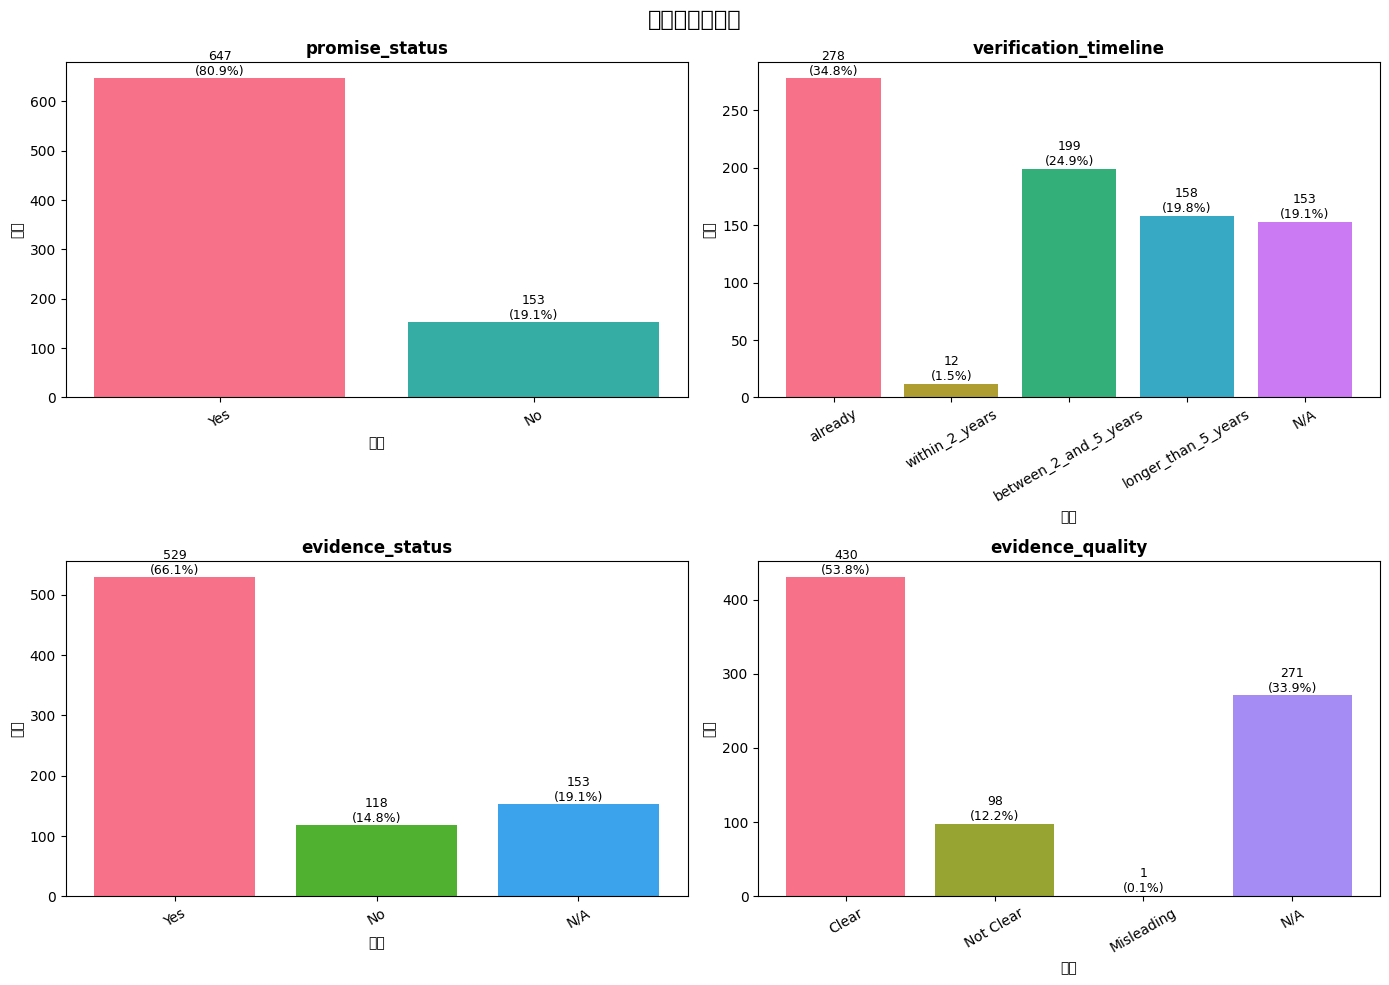

觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數


In [ ]:
# 視覺化各欄位的標籤分佈
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("訓練集標籤分佈", fontsize=16, fontweight='bold')

for idx, (field, labels) in enumerate(EVAL_FIELDS.items()):
    ax = axes[idx // 2][idx % 2]

    counts = Counter(train_df[field])
    ordered_counts = {label: counts.get(label, 0) for label in labels}

    bars = ax.bar(ordered_counts.keys(), ordered_counts.values(),
                   color=sns.color_palette("husl", len(labels)))
    ax.set_title(f"{field}", fontsize=12, fontweight='bold')
    ax.set_xlabel("標籤")
    ax.set_ylabel("數量")
    ax.tick_params(axis='x', rotation=30)

    # 在每個bar上顯示數量
    for bar, (label, count) in zip(bars, ordered_counts.items()):
        total = sum(ordered_counts.values())
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數")

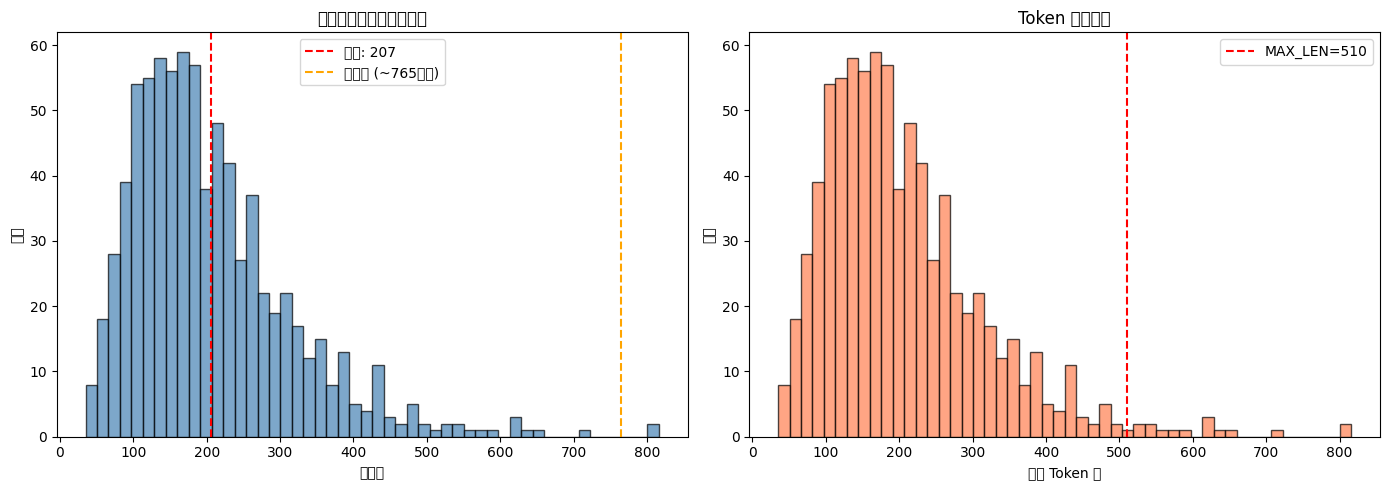

超過 MAX_LEN=510 的樣本數: 15 (1.9%)
   這些文字將被截斷，可能損失尾端資訊


In [ ]:
# 分析文字長度分佈（字元數）
train_df['text_length'] = train_df['data'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['text_length'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(train_df['text_length'].mean(), color='red', linestyle='--',
                label=f"平均: {train_df['text_length'].mean():.0f}")
axes[0].axvline(MAX_LEN * 1.5, color='orange', linestyle='--',
                label=f"截斷點 (~{MAX_LEN * 1.5:.0f}字元)")
axes[0].set_title("文字長度分佈（字元數）")
axes[0].set_xlabel("字元數")
axes[0].set_ylabel("數量")
axes[0].legend()

# Token 長度估算（中文約 1字 = 1 token）
axes[1].hist(train_df['text_length'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f"MAX_LEN={MAX_LEN}")
axes[1].set_title("Token 長度估算")
axes[1].set_xlabel("估算 Token 數")
axes[1].set_ylabel("數量")
axes[1].legend()

plt.tight_layout()
plt.show()

truncated = (train_df['text_length'] > MAX_LEN).sum()
print(f"超過 MAX_LEN={MAX_LEN} 的樣本數: {truncated} ({truncated/len(train_df)*100:.1f}%)")
print(f"   這些文字將被截斷，可能損失尾端資訊")



---



## Step 5: 建立 PyTorch Dataset

PyTorch 的 `Dataset` 類別負責：
1. 儲存資料
2. 將文字 **Tokenize**（轉換成 BERT 能理解的 Token ID）
3. 將標籤文字轉換成數字 ID

### Tokenization 是什麼？
BERT 使用 WordPiece tokenizer 將文字切成子詞單元：
- 輸入: `"台灣水泥承諾2030年碳中和"`
- 輸出: `[101, 1921, 3968, 3717, 3686, 8811, 2030, 2399, 4988, 102, ...]`
  - `101` = [CLS] 開始符號
  - `102` = [SEP] 結束符號

### Padding & Truncation
所有輸入必須等長（MAX_LEN=256），所以：
- 短文字 → 補 0（padding）
- 長文字 → 截斷（truncation）

In [ ]:
class ESGDataset(Dataset):
    """
    ESG 資料集類別

    Args:
        data: JSON 資料列表，每筆包含 'data' 文字和標籤欄位
        tokenizer: BERT tokenizer
        label2id: 標籤到 ID 的映射字典
    """
    def __init__(self, data, tokenizer, label2id):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # 將文字 Tokenize
        # - padding="max_length": 補齊到 MAX_LEN
        # - truncation=True: 超過 MAX_LEN 就截斷
        # - return_tensors="pt": 返回 PyTorch tensor
        encoding = self.tokenizer(
            item["data"],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        # 將標籤文字轉換成數字 ID
        labels = {}
        for field, mapping in self.label2id.items():
            labels[field] = mapping[item[field]]

        return {
            "input_ids": encoding["input_ids"].squeeze(0),       # Token ID 序列
            "attention_mask": encoding["attention_mask"].squeeze(0),  # 1=真實token, 0=padding
            "labels": labels,
        }


def collate_fn(batch):
    """
    將一個 batch 的樣本整合成 tensor
    因為 labels 是 dict，預設的 collate 無法處理，需自訂
    """
    input_ids = torch.stack([b["input_ids"] for b in batch])
    attention_mask = torch.stack([b["attention_mask"] for b in batch])
    labels = {
        field: torch.tensor([b["labels"][field] for b in batch])
        for field in EVAL_FIELDS
    }
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


print("Dataset 類別定義完成！")

Dataset 類別定義完成！


In [ ]:
# 示範 Tokenizer 的效果
print("Tokenizer 示範")
print("=" * 50)

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f"載入 {MODEL_NAME} tokenizer")

sample_text = train_data[0]["data"][:50]
print(f"\n原始文字：{sample_text}")

tokens = tokenizer.tokenize(sample_text)
print(f"\nTokenize 後：{tokens}")

encoding = tokenizer(sample_text, max_length=20, padding="max_length", truncation=True)
print(f"\nInput IDs (前20個)：{encoding['input_ids']}")
print(f"Attention Mask：{encoding['attention_mask']}")

Tokenizer 示範
載入 hfl/chinese-roberta-wwm-ext tokenizer

原始文字：台光電子為善盡企業社會責任，落實永續經營理念，董事會通過「企業社會責任實務守則」，2024 年 10

Tokenize 後：['台', '光', '電', '子', '為', '善', '盡', '企', '業', '社', '會', '責', '任', '，', '落', '實', '永', '續', '經', '營', '理', '念', '，', '董', '事', '會', '通', '過', '「', '企', '業', '社', '會', '責', '任', '實', '務', '守', '則', '」', '，', '202', '##4', '年', '10']

Input IDs (前20個)：[101, 1378, 1045, 7442, 2094, 4158, 1587, 4674, 821, 3511, 4852, 3298, 6519, 818, 8024, 5862, 2179, 3719, 5265, 102]
Attention Mask：[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
from imblearn.over_sampling import RandomOverSampler
import random

# 定義一個簡單的資料增強函式
def augment_text(text):
    words = list(text)
    if len(words) < 5: return text

    op = random.random()
    if op < 0.25: # 隨機交換
        idx = random.randint(0, len(words)-2)
        words[idx], words[idx+1] = words[idx+1], words[idx]
    elif op < 0.5: # 隨機刪除一個字
        idx = random.randint(0, len(words)-1)
        words.pop(idx)

    return "".join(words)

# 為了方便 OverSampling，我們建立一個複合標籤代表四個任務的組合
train_df = pd.DataFrame(train_data)
train_df['combined_label'] = train_df[list(EVAL_FIELDS.keys())].astype(str).agg('-'.join, axis=1)

# 執行 Random Oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, _ = ros.fit_resample(train_df[['data', 'id']], train_df['combined_label'])

# 取得平衡後的資料並套用增強
balanced_train_data = []
resampled_indices = ros.sample_indices_

# 進階資料增強：加入更多隨機擾動
def advanced_augment(text):
    words = list(text)
    length = len(words)
    if length < 10: return text

    # 隨機選擇增強策略
    strategy = random.random()

    if strategy < 0.3: # 隨機交換 (擴大範圍)
        for _ in range(2):
            idx = random.randint(0, length - 2)
            words[idx], words[idx+1] = words[idx+1], words[idx]
    elif strategy < 0.6: # 隨機刪除 (針對標點或虛字)
        for _ in range(random.randint(1, 3)):
            idx = random.randint(0, len(words) - 1)
            words.pop(idx)
    else: # 隨機插入 (複製現有字元到隨機位置)
        for _ in range(2):
            char_to_dup = words[random.randint(0, length - 1)]
            words.insert(random.randint(0, len(words)), char_to_dup)

    return "".join(words)

In [ ]:
import random
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# 1. 建立 DataFrame 並生成複合標籤
train_df_to_expand = pd.DataFrame(train_data)
train_df_to_expand['combined_label'] = train_df_to_expand[list(EVAL_FIELDS.keys())].astype(str).agg('-'.join, axis=1)

# 2. 修改擴張策略：為了解決 promise_status 不平均，我們手動調高包含 'No' 的標籤組合的目標數量
current_counts = train_df_to_expand['combined_label'].value_counts()
max_samples = current_counts.max()

# 策略：讓所有類別都至少達到一定的數量，特別是針對 promise_status 為 No 的組合進行補強
strategy = {}
for label, count in current_counts.items():
    # 如果標籤組合中包含 promise_status 為 'No' (通常在組合字串的第一部分)
    if label.startswith('No'):
        strategy[label] = max(count, 500) # 強制提升 No 類別的樣本數
    else:
        strategy[label] = max(count, 150) # Yes 類別維持適中

ros_mega = RandomOverSampler(sampling_strategy=strategy, random_state=42)

# 3. 執行擴張
_, _ = ros_mega.fit_resample(train_df_to_expand[['data']], train_df_to_expand['combined_label'])
resampled_indices = ros_mega.sample_indices_

# 4. 套用增強並重新產生訓練集
extended_train_data = []
for i, idx in enumerate(resampled_indices):
    # 使用 original_train_data 確保從最原始的 1000 筆中抓取 (假設最原始資料存放在 all_data 或初始 train_data)
    # 這裡我們使用 train_df_to_expand 的原始索引
    item = train_data[idx].copy()

    # 只要是重複出的樣本，或是隨機觸發，就套用增強以增加變化性
    if i >= len(train_df_to_expand) or random.random() > 0.5:
        item['data'] = advanced_augment(item['data'])
    extended_train_data.append(item)

# 更新最終訓練集變數
train_data = extended_train_data
print(f"修正後的擴張完成！")
print(f"   最終訓練集規模: {len(train_data)} 筆")
print(f"   驗證集規模: {len(test_data)} 筆")

修正後的擴張完成！
   最終訓練集規模: 2370 筆
   驗證集規模: 2000 筆


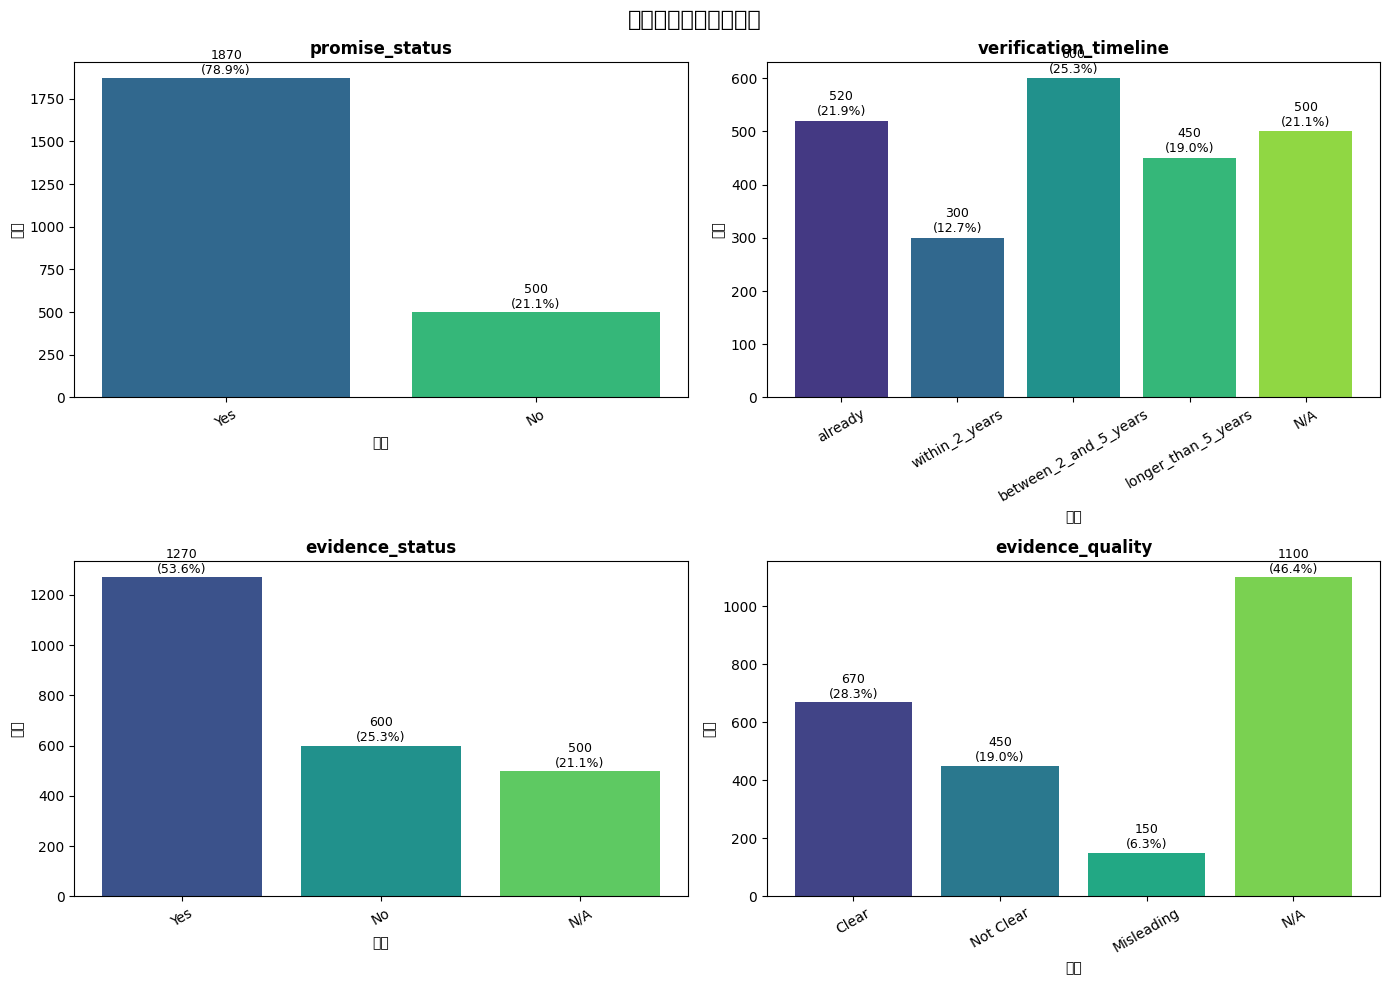

觀察：擴增後的資料集在各欄位的分佈應較為平衡，特別是原本樣本極少的類別（如 Misleading 或 longer_than_5_years）現在應有顯著增加。


In [ ]:
# 轉換擴增後的資料為 DataFrame
extended_train_df = pd.DataFrame(train_data)

# 視覺化擴增後各欄位的標籤分佈
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("擴增後訓練集標籤分佈", fontsize=16, fontweight='bold')

for idx, (field, labels) in enumerate(EVAL_FIELDS.items()):
    ax = axes[idx // 2][idx % 2]

    # 計算擴增後的數量
    counts = Counter(extended_train_df[field])
    ordered_counts = {label: counts.get(label, 0) for label in labels}

    bars = ax.bar(ordered_counts.keys(), ordered_counts.values(),
                   color=sns.color_palette("viridis", len(labels)))
    ax.set_title(f"{field}", fontsize=12, fontweight='bold')
    ax.set_xlabel("標籤")
    ax.set_ylabel("數量")
    ax.tick_params(axis='x', rotation=30)

    # 在每個 bar 上顯示數量與百分比
    total_samples = sum(ordered_counts.values())
    for bar, (label, count) in zip(bars, ordered_counts.items()):
        pct = (count / total_samples * 100) if total_samples > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("extended_label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("觀察：擴增後的資料集在各欄位的分佈應較為平衡，特別是原本樣本極少的類別（如 Misleading 或 longer_than_5_years）現在應有顯著增加。")

In [ ]:
# 4. 重新建立 DataLoader
# 確保訓練使用擴增後的 train_data，驗證使用有標籤的 val_data
train_dataset = ESGDataset(train_data, tokenizer, label2id)
val_dataset   = ESGDataset(val_data,   tokenizer, label2id)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, pin_memory=True)

print("DataLoader 已更新，請重新執行模型初始化與訓練。")

DataLoader 已更新，請重新執行模型初始化與訓練。




---



## Step 6: 模型架構設計

我們使用 **Multi-Task Learning（多任務學習）**：
- 共用同一個 BERT backbone（特徵提取器）
- 每個任務有自己獨立的分類頭（Linear Layer）

### 架構圖
```
文字輸入
   ↓
[BERT Encoder] × 12 層 Transformer
   ↓
[CLS] Token 向量 (768維)
   ↓
┌──────────────────────────────────────────┐
│  promise_status    → Linear(768, 2)  → 2個類別  │
│  verification_timeline → Linear(768, 5) → 5個類別  │
│  evidence_status   → Linear(768, 3)  → 3個類別  │
│  evidence_quality  → Linear(768, 4)  → 4個類別  │
└──────────────────────────────────────────┘
```

### 為什麼用 [CLS] Token？
BERT 的第一個 token `[CLS]` 的輸出向量被設計用於表示整個句子的語意，
因此適合用於句子分類任務。

In [ ]:
class MultiTaskBert(nn.Module):
    """
    多任務 BERT 分類模型

    加入 Dropout 防止過擬合
    """
    def __init__(self, num_labels_dict, dropout_rate=0.1):
        super().__init__()

        # 載入預訓練 BERT 模型
        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden_size = self.bert.config.hidden_size  # 768

        # 加入 Dropout 層
        self.dropout = nn.Dropout(dropout_rate)

        # 為每個任務建立獨立的分類頭
        self.classifiers = nn.ModuleDict({
            field: nn.Linear(hidden_size, n)
            for field, n in num_labels_dict.items()
        })

    def forward(self, input_ids, attention_mask):
        # BERT 前向傳播
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        # pooler_output: [CLS] token 向量, shape=[batch, 768]
        pooled = outputs.pooler_output

        # 在分類前套用 Dropout
        pooled = self.dropout(pooled)

        # 每個任務計算 logits
        logits = {
            field: clf(pooled)
            for field, clf in self.classifiers.items()
        }
        return logits

# 重新初始化模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiTaskBert(num_labels).to(device)
print(f"模型已更新，已加入 Dropout (rate=0.1)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: hfl/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


模型已更新，已加入 Dropout (rate=0.1)




---



## Step 7: 定義訓練與評估函數

### 損失函數
我們使用 **CrossEntropyLoss**（交叉熵損失），適用於多分類問題。

對於多任務，損失 = 各任務損失的加總：
```
total_loss = loss(promise_status) + loss(timeline) + loss(evidence_status) + loss(evidence_quality)
```

### 優化器與學習率排程
- **AdamW**：Adam 的改進版，加入 weight decay 防止過擬合
- **Linear Warmup + Decay**：先線性增加學習率（warmup），再線性衰減
  - 前 10% 步數：學習率從 0 增加到 LR
  - 後 90% 步數：學習率從 LR 線性衰減到 0

### Gradient Clipping
`clip_grad_norm_(model.parameters(), 1.0)` — 防止梯度爆炸，將梯度範數裁剪到最大為 1.0

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 儲存每個欄位的權重 Tensor
field_class_weights = {}

print("計算各任務類別權重：")
for field, labels in EVAL_FIELDS.items():
    y_train = np.array([item[field] for item in train_data])
    classes_array = np.array(labels)

    # 計算權重 (使用 'balanced' 模式)
    weights = compute_class_weight(class_weight='balanced', classes=classes_array, y=y_train)
    field_class_weights[field] = torch.tensor(weights, dtype=torch.float).to(device)
    print(f"  {field}: {weights.round(2)}")

計算各任務類別權重：
  promise_status: [0.63 2.37]
  verification_timeline: [0.91 1.58 0.79 1.05 0.95]
  evidence_status: [0.62 1.32 1.58]
  evidence_quality: [0.88 1.32 3.95 0.54]


In [ ]:
def train_one_epoch_weighted(model, dataloader, optimizer, scheduler, device, weights_dict):
    model.train()
    total_loss = 0

    # 為每個任務建立帶有權重的損失函數
    criterions = {field: nn.CrossEntropyLoss(weight=weights_dict[field]) for field in EVAL_FIELDS}

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        logits = model(input_ids, attention_mask)

        # 使用對應的權重損失函數計算
        loss = sum(
            criterions[field](logits[field], batch["labels"][field].to(device))
            for field in EVAL_FIELDS
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

print("已定義加權損失訓練函數。")

已定義加權損失訓練函數。


In [ ]:
def train_one_epoch(model, dataloader, optimizer, scheduler, device):
    """
    訓練一個 epoch

    Returns:
        avg_loss: 平均損失值
    """
    model.train()  # 切換到訓練模式（啟用 Dropout 等）
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    for step, batch in enumerate(dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # 前向傳播
        logits = model(input_ids, attention_mask)

        # 計算所有任務的損失總和
        loss = sum(
            criterion(logits[field], batch["labels"][field].to(device))
            for field in EVAL_FIELDS
        )

        # 反向傳播
        optimizer.zero_grad()    # 清除上一步的梯度
        loss.backward()          # 計算梯度
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 梯度裁剪
        optimizer.step()         # 更新參數
        scheduler.step()         # 更新學習率

        total_loss += loss.item()

        # 每50步顯示進度
        if (step + 1) % 50 == 0:
            print(f"  Step {step+1}/{len(dataloader)}, Loss: {loss.item():.4f}")

    return total_loss / len(dataloader)


def predict(model, dataloader, device, id2label):
    """
    對資料集進行預測

    Returns:
        predictions: 每筆資料的預測結果（字典列表）
    """
    model.eval()  # 切換到評估模式（關閉 Dropout）
    predictions = []

    with torch.no_grad():  # 不計算梯度，節省記憶體
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)

            batch_size = input_ids.size(0)
            for i in range(batch_size):
                pred = {}
                for field in EVAL_FIELDS:
                    # argmax 取得最高分的類別 ID
                    pred_id = logits[field][i].argmax().item()
                    pred[field] = id2label[field][pred_id]
                predictions.append(pred)

    return predictions


print("訓練與預測函數定義完成！")

訓練與預測函數定義完成！


In [ ]:
def evaluate_hybrid(gt_data, pred_data):
    """
    混合評估函數：加權 Macro F1

    Args:
        gt_data: Ground truth 資料列表
        pred_data: 預測結果列表（順序需與 gt_data 一致）

    Returns:
        results: 各欄位的評估結果 + 最終加權分數
    """
    assert len(gt_data) == len(pred_data), \
        f"筆數不符：gt={len(gt_data)}, pred={len(pred_data)}"

    results = {}
    weighted_score = 0.0

    for field, labels in EVAL_FIELDS.items():
        y_true = [item[field] for item in gt_data]
        y_pred = [item[field] for item in pred_data]

        # Macro F1: 每個類別分別計算 F1，再取平均（不考慮類別數量）
        macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
        # Micro F1: 全部類別合併計算（考慮類別數量）
        micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        report   = classification_report(y_true, y_pred, labels=labels, zero_division=0)

        weight = FIELD_WEIGHTS.get(field, 0)
        weighted_score += macro_f1 * weight

        results[field] = {
            "macro_f1": macro_f1,
            "micro_f1": micro_f1,
            "report": report,
            "weight": weight
        }

    results["final_weighted_score"] = weighted_score
    return results


print(" 評估函數定義完成！")
print("\n Macro F1 vs Micro F1 說明：")
print("   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別")
print("   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標")

 評估函數定義完成！

 Macro F1 vs Micro F1 說明：
   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別
   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標




---



## Step 8: 開始訓練！

現在所有準備工作都就緒，讓我們開始訓練模型！

### 訓練流程
```
for epoch in range(EPOCHS):
    1. 訓練一個 epoch（更新模型參數）
    2. 在驗證集上預測
    3. 計算評估指標
    4. 如果是最佳模型，儲存權重
```

### 預期時間（Colab T4 GPU）
- 每個 epoch 約 3-5 分鐘
- 5 個 epoch 共約 15-25 分鐘

> **提示**：如果使用 CPU，速度會慢很多（約 10倍），建議使用 Colab GPU 執行

In [ ]:
# 設定優化器與學習率排程器
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"訓練設定：")
print(f"   Total steps: {total_steps}")
print(f"   Warmup steps: {warmup_steps} (前 10%)")
print(f"   Learning rate: {LR}")
print(f"   Optimizer: AdamW")

訓練設定：
   Total steps: 1485
   Warmup steps: 148 (前 10%)
   Learning rate: 2e-05
   Optimizer: AdamW


In [ ]:
# ============================================================
# 主訓練迴圈
# ============================================================
MODEL_SAVE_PATH = "best_model.pt"

best_score = 0.0
history = {"loss": [], "weighted_score": [], "lr": []}

print("開始訓練！")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    # 訓練
    avg_loss = train_one_epoch_weighted(model, train_loader, optimizer, scheduler, device, field_class_weights)
    history["loss"].append(avg_loss)
    print(f"  平均 Loss: {avg_loss:.4f}")

    # 評估
    preds = predict(model, val_loader, device, id2label)
    results = evaluate_hybrid(val_data, preds)

    current_score = results["final_weighted_score"]
    history["weighted_score"].append(current_score)

    print(f"\n  加權分數: {current_score:.5f}")
    for field in EVAL_FIELDS:
        r = results[field]
        print(f"     {field}: Macro F1={r['macro_f1']:.4f} (權重={r['weight']})")

    # 取得當前學習率紀錄
    current_lr = optimizer.param_groups[0]['lr']
    history["lr"].append(current_lr)
    print(f"  當前學習率: {current_lr:.2e}")

    # 儲存最佳模型
    if current_score > best_score:
        best_score = current_score
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"\n 最佳模型已儲存！分數: {best_score:.5f}")

print(f"\n{'=' * 60}")
print(f"訓練完成！最佳加權分數: {best_score:.5f}")

開始訓練！

Epoch 1/5
----------------------------------------
  平均 Loss: 1.2056

  加權分數: 0.54974
     promise_status: Macro F1=0.7576 (權重=0.2)
     verification_timeline: Macro F1=0.4430 (權重=0.15)
     evidence_status: Macro F1=0.6031 (權重=0.3)
     evidence_quality: Macro F1=0.4310 (權重=0.35)
  當前學習率: 1.33e-05

 最佳模型已儲存！分數: 0.54974

Epoch 2/5
----------------------------------------
  平均 Loss: 0.4711

  加權分數: 0.59255
     promise_status: Macro F1=0.8399 (權重=0.2)
     verification_timeline: Macro F1=0.4723 (權重=0.15)
     evidence_status: Macro F1=0.6849 (權重=0.3)
     evidence_quality: Macro F1=0.4236 (權重=0.35)
  當前學習率: 8.89e-06

 最佳模型已儲存！分數: 0.59255

Epoch 3/5
----------------------------------------
  平均 Loss: 0.1994

  加權分數: 0.54377
     promise_status: Macro F1=0.7569 (權重=0.2)
     verification_timeline: Macro F1=0.4474 (權重=0.15)
     evidence_status: Macro F1=0.6256 (權重=0.3)
     evidence_quality: Macro F1=0.3932 (權重=0.35)
  當前學習率: 4.44e-06

Epoch 4/5
------------------------------------

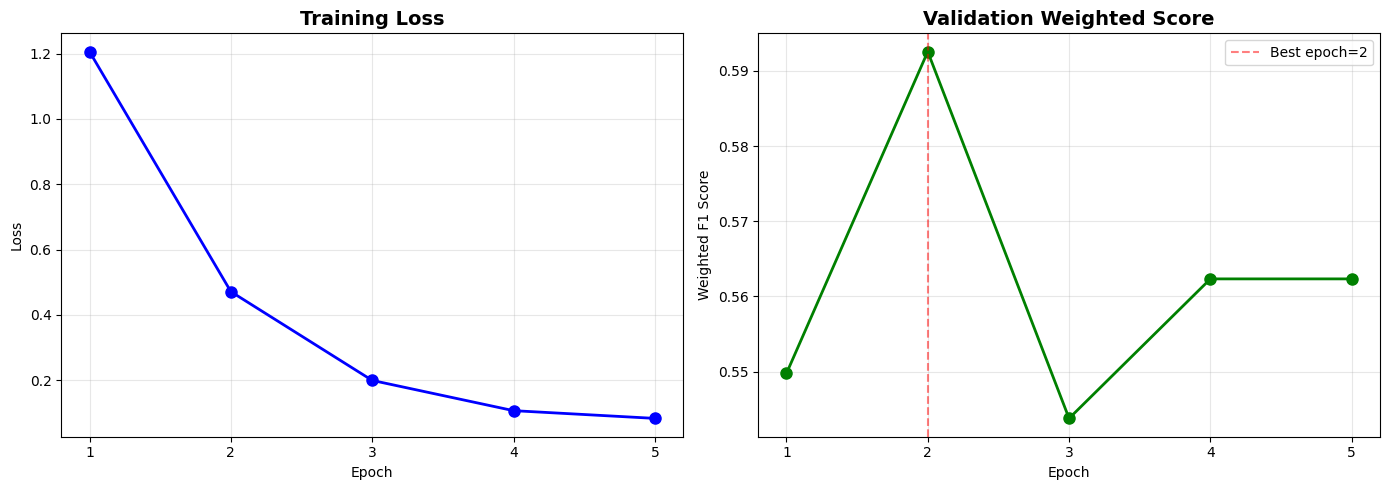

In [ ]:
# 繪製訓練曲線
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["loss"], 'b-o', linewidth=2, markersize=8)
axes[0].set_title("Training Loss", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, history["weighted_score"], 'g-o', linewidth=2, markersize=8)
axes[1].set_title("Validation Weighted Score", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weighted F1 Score")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_range)

# 標記最佳點
best_epoch = history["weighted_score"].index(max(history["weighted_score"])) + 1
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch={best_epoch}')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches='tight')
plt.show()



---



## Step 9: 最終評估與結果分析

訓練完成後，載入最佳模型並進行詳細的結果分析。

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# 1. 載入最佳模型權重
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()
print("已載入最佳模型")

# 2. 讀取測試資料集 (CSV)
test_df = pd.read_csv('vpesg4k_test_2000.csv')
# 轉換為 Dataset 格式所需的 list of dict
test_data_list = test_df.to_dict('records')

# 3. 建立測試用的 DataLoader
class TestDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        encoding = self.tokenizer(
            item["data"],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0)
        }

def test_predict(model, dataloader, device, id2label):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)

            batch_size = input_ids.size(0)
            for i in range(batch_size):
                pred = {}
                for field in EVAL_FIELDS:
                    pred_id = logits[field][i].argmax().item()
                    pred[field] = id2label[field][pred_id]
                predictions.append(pred)
    return predictions

test_dataset = TestDataset(test_data_list, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 4. 執行預測
print("正在進行測試集預測...")
test_preds = test_predict(model, test_loader, device, id2label)

# 5. 整合結果並輸出符合 AIdea 規範的 CSV
results_df = pd.DataFrame(test_data_list)
preds_df = pd.DataFrame(test_preds)

# 合併原始資料與預測結果
final_output = pd.concat([results_df, preds_df], axis=1)

# 只擷取官方要求的欄位（排除原本的 data 欄位），確保欄位與順序完全一致
submit_columns = ['id'] + list(EVAL_FIELDS.keys())
final_submit = final_output[submit_columns]

# 儲存 CSV
OUTPUT_CSV = "test_predictions.csv"
# 使用 utf-8 (無BOM) 並且指定 Unix 換行符號 \n
final_submit.to_csv(OUTPUT_CSV, index=False, encoding='utf-8', lineterminator='\n')

print(f"\n{'=' * 60}")
print(f"預測完成！結果已儲存至: {OUTPUT_CSV}")
print(f"預測筆數: {len(final_submit)}")
print(f"{'=' * 60}")

# 顯示前幾筆結果（確認欄位是否乾淨正確）
display(final_submit.head())

已載入最佳模型
正在進行測試集預測...

預測完成！結果已儲存至: test_predictions.csv
預測筆數: 2000


,id,promise_status,verification_timeline,evidence_status,evidence_quality
0,12001,Yes,between_2_and_5_years,Yes,Clear
1,12002,Yes,already,Yes,Clear
2,12003,Yes,already,Yes,Clear
3,12004,Yes,already,Yes,Clear
4,12005,Yes,already,Yes,Clear
